In [1]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from devmap.utils import save_plot
from devmap.config import set_theme, discrete_cmap
import matplotlib.colors as mcolors
import re

In [5]:
adata = sc.read_h5ad("../data/qiu24_late_integrated_scvi.h5ad")

In [7]:
n_to_subsample = 500_000
if adata.n_obs > n_to_subsample:
    print(f"subsampling from {adata.n_obs} to {n_to_subsample} cells")
    adata = adata[np.random.choice(adata.n_obs, n_to_subsample, replace=False)]

sc.pp.neighbors(adata, use_rep='X_scvi')

Subsampling from 3823378 to 500000 cells for faster plotting


In [8]:
sc.tl.umap(adata, random_state=0)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

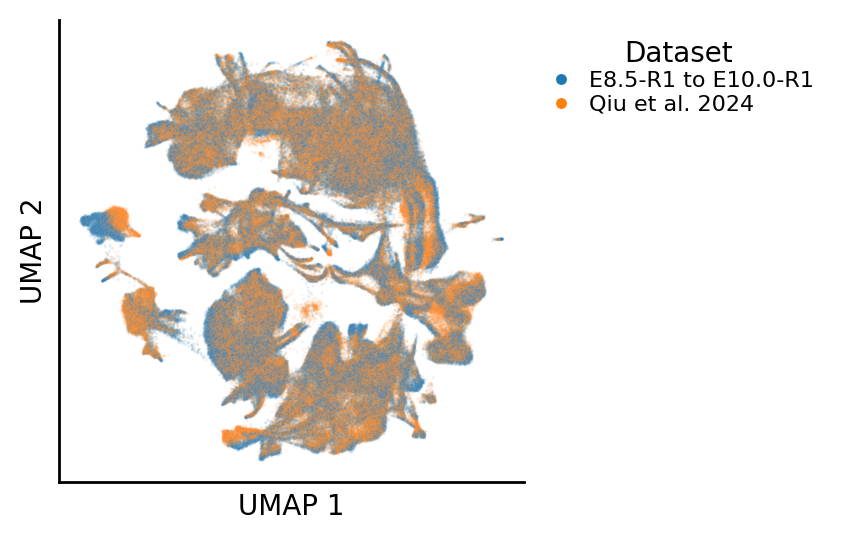

In [ ]:
set_theme()
fig, axes = plt.subplots(1, 2, figsize=(7, 3), dpi=200)
name_mapping = {
    'qiu2024': 'Qiu et al. 2024',
    'devmap': 'E7.5-R1 to E8.5-R3'
}
ax = axes[0]
dataset_labels = [name_mapping.get(x, x) for x in adata.obs["dataset"]]
sns.scatterplot(
    x=adata.obsm["X_umap"][:, 0],
    y=adata.obsm["X_umap"][:, 1],
    hue=dataset_labels,
    s=1, alpha=0.1,
    rasterized=True,
    legend=True,
    ax=ax,
)
handles, labels = ax.get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(1)
    handle.set_markersize(6)
ax.legend(
    handles, labels,
    title="Dataset", loc='upper left', bbox_to_anchor=(1, 1),
    markerscale=1, fontsize=8, frameon=False,
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

ax = axes[1]
dark_purple = '#2D004B'

# Split into 7.25 vs rest
mask_725 = adata.obs['timepoint'] == 7.25
mask_rest = ~mask_725

# Plot  with rainbow colormap
sns.scatterplot(
    x=adata.obsm["X_umap"][mask_rest, 0],
    y=adata.obsm["X_umap"][mask_rest, 1],
    hue=adata.obs['timepoint'][mask_rest],
    s=1, alpha=0.1,
    palette='rainbow', hue_norm=(7.5, 10.0),
    rasterized=True,
    legend=True,
    ax=ax,
)

# Build legend: prepend 7.25 entry manually
handles, labels = ax.get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(1)
    handle.set_markersize(6)
purple_handle = plt.Line2D([], [], marker='o', color='w', markerfacecolor=dark_purple,
                           markersize=7, linestyle='None')
handles = [purple_handle] + handles
labels = ['7.25'] + labels

ax.legend(
    handles, labels,
    title="Timepoint", loc='upper left', bbox_to_anchor=(1, 1),
    markerscale=1, fontsize=8, frameon=False,
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
save_plot("integration/early_integration_umap.svg", fig)
plt.show()

In [6]:
adata = sc.read_h5ad("../data/qiu22_early_integrated_scvi.h5ad")

adata_qiu = adata[adata.obs["dataset"] == "qiu2022"]
adata_qiu = adata_qiu[~adata_qiu.obs['day'].isin(['E6.5', 'E6.75', 'E7'])]
adata_devmap = adata[adata.obs["dataset"] == "devmap"]

# subsample devmap to match qiu
n_to_subsample = adata_qiu.n_obs
if adata_devmap.n_obs > n_to_subsample:
    print(f"subsampling devmap from {adata_devmap.n_obs} to {n_to_subsample} cells")
    adata_devmap = adata_devmap[np.random.choice(adata_devmap.n_obs, n_to_subsample, replace=False)]

subsampling devmap from 115984 to 88549 cells


In [7]:
adata = adata_qiu.concatenate(adata_devmap)

sc.pp.neighbors(adata, use_rep='X_scvi', n_neighbors=30)

sc.tl.umap(adata, random_state=0)

/tmp/ipykernel_142153/1319189784.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_qiu.concatenate(adata_devmap)


In [8]:
day_vals = adata.obs['day'].str.replace('E', '', regex=False).str.replace('a', '', regex=False).astype(float)
adata.obs['timepoint'] = day_vals.fillna(adata.obs['time'])

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

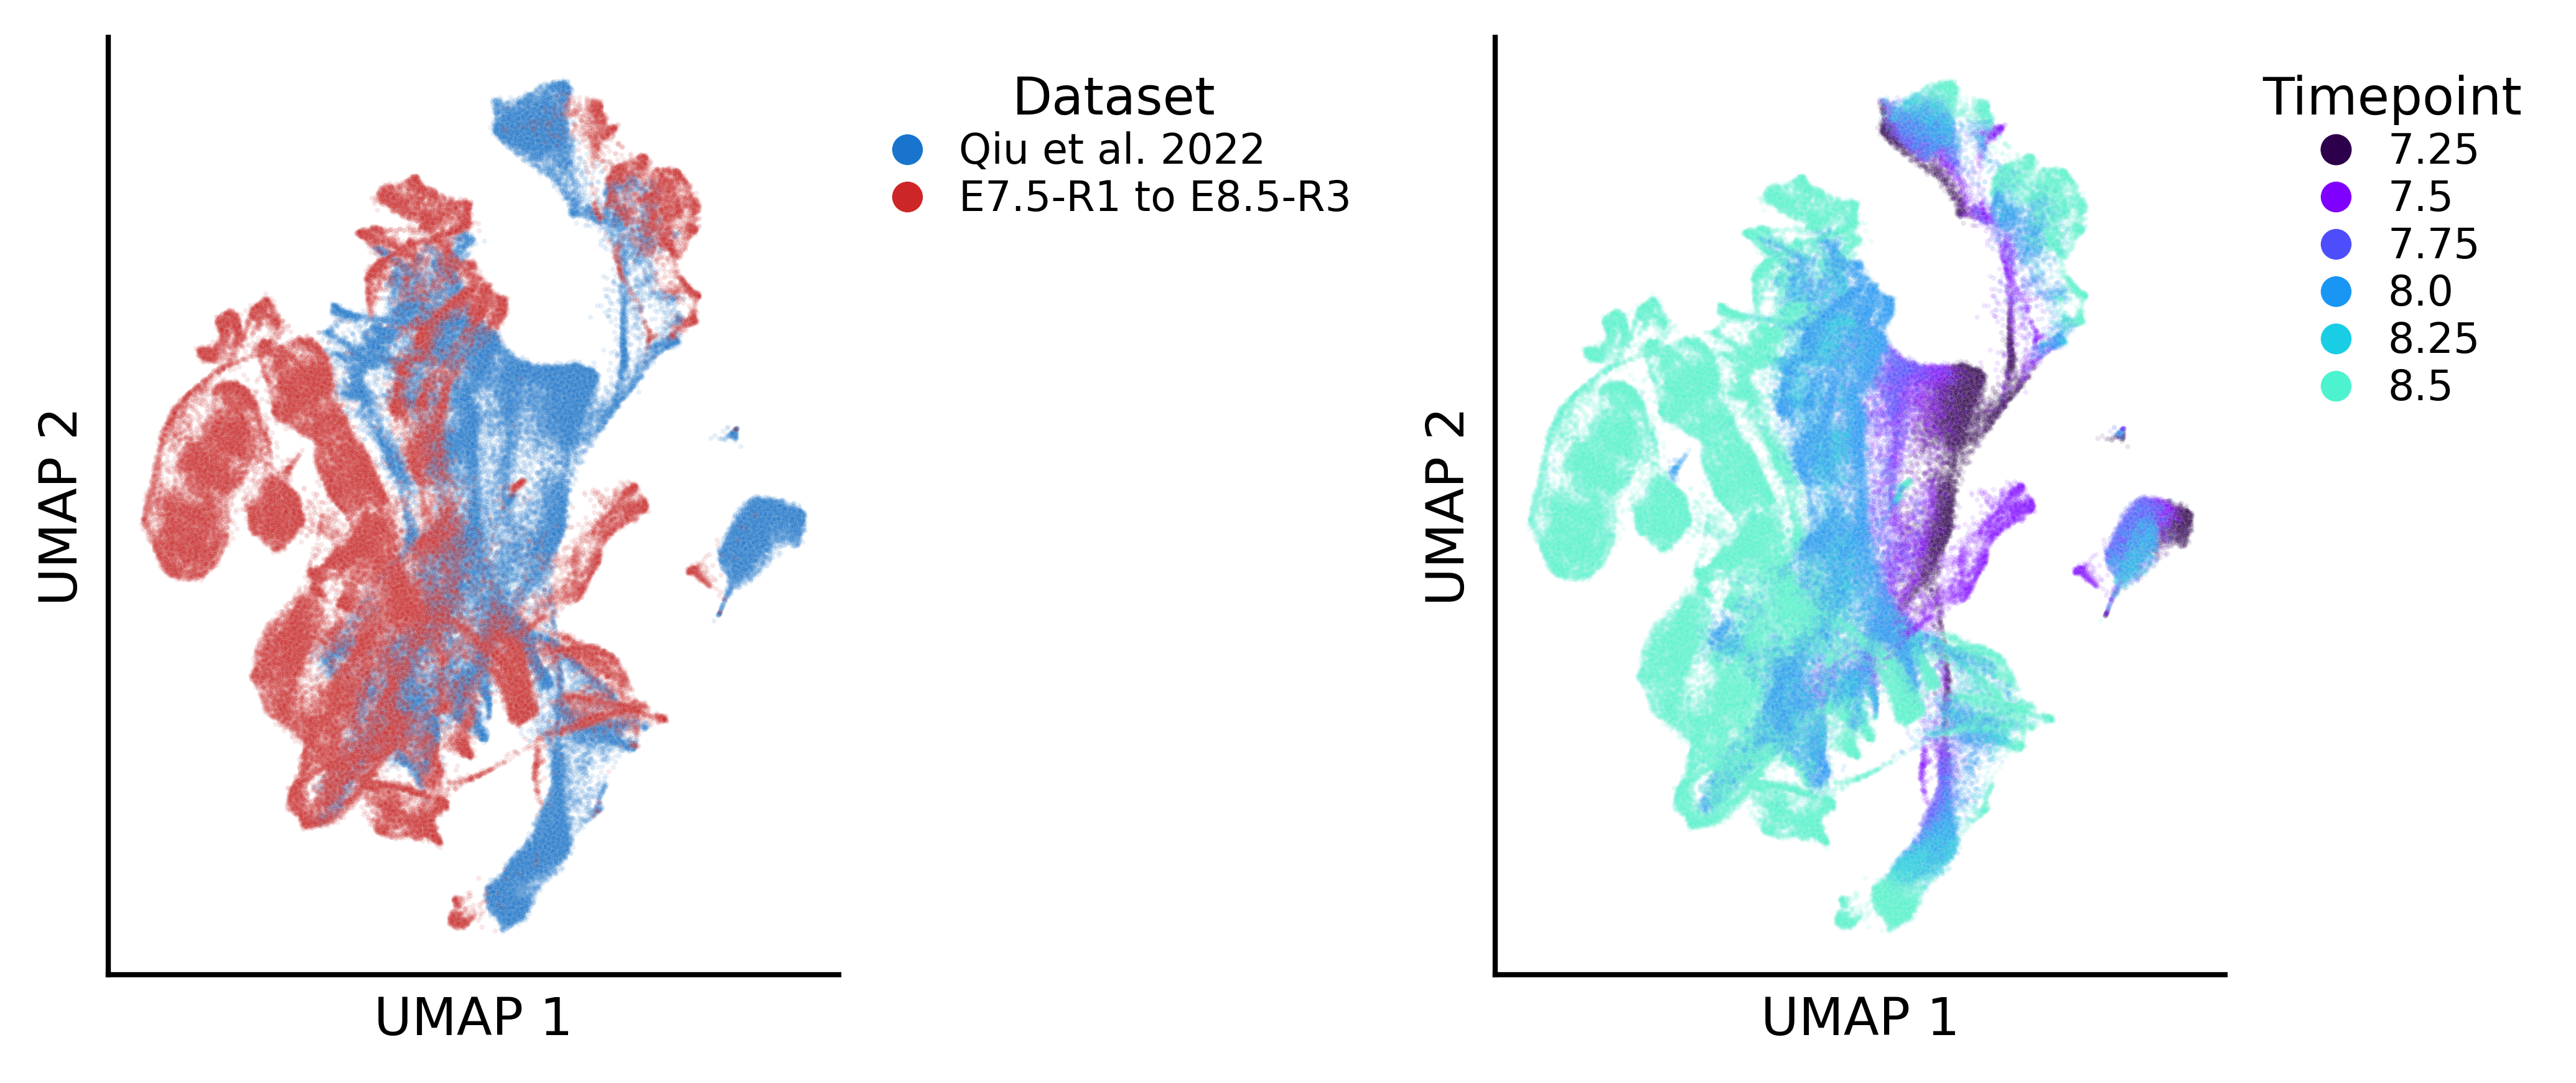

In [10]:
set_theme()
fig, axes = plt.subplots(1, 2, figsize=(7, 3), dpi=600)
name_mapping = {
    'qiu2022': 'Qiu et al. 2022',
    'devmap': 'E7.5-R1 to E8.5-R3'
}
ax = axes[0]
dataset_labels = [name_mapping.get(x, x) for x in adata.obs["dataset"]]
sns.scatterplot(
    x=adata.obsm["X_umap"][:, 0],
    y=adata.obsm["X_umap"][:, 1],
    hue=dataset_labels,
    s=1, alpha=0.1,
    rasterized=True,
    legend=True,
    ax=ax,
)
handles, labels = ax.get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(1)
    handle.set_markersize(6)
ax.legend(
    handles, labels,
    title="Dataset", loc='upper left', bbox_to_anchor=(1, 1),
    markerscale=1, fontsize=8, frameon=False,
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

ax = axes[1]
dark_purple = '#2D004B'

# Split into 7.25 vs rest
mask_725 = adata.obs['timepoint'] == 7.25
mask_rest = ~mask_725

# Plot 7.25 first (background) with fixed color
sns.scatterplot(
    x=adata.obsm["X_umap"][mask_725, 0],
    y=adata.obsm["X_umap"][mask_725, 1],
    color=dark_purple,
    s=1, alpha=0.1,
    rasterized=True,
    legend=False,
    ax=ax,
)

# Plot rest with rainbow colormap
sns.scatterplot(
    x=adata.obsm["X_umap"][mask_rest, 0],
    y=adata.obsm["X_umap"][mask_rest, 1],
    hue=adata.obs['timepoint'][mask_rest],
    s=1, alpha=0.1,
    palette='rainbow', hue_norm=(7.5, 10.0),
    rasterized=True,
    legend=True,
    ax=ax,
)

# Build legend: prepend 7.25 entry manually
handles, labels = ax.get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(1)
    handle.set_markersize(6)
purple_handle = plt.Line2D([], [], marker='o', color='w', markerfacecolor=dark_purple,
                           markersize=7, linestyle='None')
handles = [purple_handle] + handles
labels = ['7.25'] + labels

ax.legend(
    handles, labels,
    title="Timepoint", loc='upper left', bbox_to_anchor=(1, 1),
    markerscale=1, fontsize=8, frameon=False,
)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
save_plot("integration/early_integration_umap.svg", fig)
plt.show()